In [167]:
#Danisa Alternative - add baseline features 

### import necessary packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np

In [168]:
### import data
data= pd.read_csv("./brca_metabric_clinical_data.tsv", sep="\t")
data.head(10)

,Study ID,Patient ID,Sample ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,...,Relapse Free Status (Months),Relapse Free Status,Number of Samples Per Patient,Sample Type,Sex,3-Gene classifier subtype,TMB (nonsynonymous),Tumor Size,Tumor Stage,Patient's Vital Status
0,brca_metabric,MB-0000,MB-0000,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,NO,claudin-low,...,140.500000,0:Not Recurred,1,Primary,Female,ER-/HER2-,0.000000,22.0,2.0,Living
1,brca_metabric,MB-0002,MB-0002,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,NO,LumA,...,84.633333,0:Not Recurred,1,Primary,Female,ER+/HER2- High Prolif,2.615035,10.0,1.0,Living
2,brca_metabric,MB-0005,MB-0005,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,YES,LumB,...,153.300000,1:Recurred,1,Primary,Female,NaN,2.615035,15.0,2.0,Died of Disease
3,brca_metabric,MB-0006,MB-0006,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,YES,LumB,...,164.933333,0:Not Recurred,1,Primary,Female,NaN,1.307518,25.0,2.0,Living
4,brca_metabric,MB-0008,MB-0008,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,YES,LumB,...,18.800000,1:Recurred,1,Primary,Female,ER+/HER2- High Prolif,2.615035,40.0,2.0,Died of Disease
5,brca_metabric,MB-0010,MB-0010,78.77,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,NO,LumB,...,2.933333,1:Recurred,1,Primary,Female,ER+/HER2- High Prolif,5.230071,31.0,4.0,Died of Disease
6,brca_metabric,MB-0014,MB-0014,56.45,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,YES,LumB,...,164.333333,0:Not Recurred,1,Primary,Female,NaN,5.230071,10.0,2.0,Living
7,brca_metabric,MB-0020,MB-0020,70.00,MASTECTOMY,Breast Cancer,Breast Invasive Lobular Carcinoma,High,YES,Normal,...,11.900000,1:Recurred,1,Primary,Female,ER-/HER2-,0.000000,65.0,3.0,Died of Disease
8,brca_metabric,MB-0022,MB-0022,89.08,BREAST CONSERVING,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,NO,claudin-low,...,99.533333,0:Not Recurred,1,Primary,Female,NaN,1.307518,29.0,2.0,Died of Other Causes
9,brca_metabric,MB-0025,MB-0025,76.24,NaN,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,NaN,NaN,...,128.000000,1:Recurred,1,Primary,Female,NaN,6.537589,34.0,2.0,NaN


In [169]:
### feature selection

# list of features to keep
# this time, we add features of immunohistochemistry.
keep_columns=["Age at Diagnosis", 
              "Cancer Type Detailed", 
              "Inferred Menopausal State", 
              "Tumor Size",
              "Lymph nodes examined positive",
              "3-Gene classifier subtype",
              "Pam50 + Claudin-low subtype",
              "Integrative Cluster",
              "ER Status",
              "PR Status",
              "HER2 Status",
              "Overall Survival (Months)"]

# remove other features
data = data[keep_columns].copy()

# confirm removal
print(data.columns)

# remove samples where Overall Survival is na
data = data.dropna(subset=["Overall Survival (Months)"])

Index(['Age at Diagnosis', 'Cancer Type Detailed', 'Inferred Menopausal State',
       'Tumor Size', 'Lymph nodes examined positive',
       '3-Gene classifier subtype', 'Pam50 + Claudin-low subtype',
       'Integrative Cluster', 'ER Status', 'PR Status', 'HER2 Status',
       'Overall Survival (Months)'],
      dtype='str')


In [170]:
###Inspect the raw data
data.info()

<class 'pandas.DataFrame'>
Index: 1981 entries, 0 to 1984
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age at Diagnosis               1981 non-null   float64
 1   Cancer Type Detailed           1981 non-null   str    
 2   Inferred Menopausal State      1980 non-null   str    
 3   Tumor Size                     1955 non-null   float64
 4   Lymph nodes examined positive  1905 non-null   float64
 5   3-Gene classifier subtype      1764 non-null   str    
 6   Pam50 + Claudin-low subtype    1980 non-null   str    
 7   Integrative Cluster            1980 non-null   str    
 8   ER Status                      1981 non-null   str    
 9   PR Status                      1980 non-null   str    
 10  HER2 Status                    1980 non-null   str    
 11  Overall Survival (Months)      1981 non-null   float64
dtypes: float64(4), str(8)
memory usage: 201.2 KB


In [171]:
# Missing data por feature
missing_df = pd.DataFrame({
    "missing_count": data.isna().sum(),
    "missing_pct": (data.isna().mean() * 100).round(2)
}).sort_values("missing_count", ascending=False)

print(missing_df)

                               missing_count  missing_pct
3-Gene classifier subtype                217        10.95
Lymph nodes examined positive             76         3.84
Tumor Size                                26         1.31
Inferred Menopausal State                  1         0.05
Pam50 + Claudin-low subtype                1         0.05
Integrative Cluster                        1         0.05
PR Status                                  1         0.05
HER2 Status                                1         0.05
Age at Diagnosis                           0         0.00
Cancer Type Detailed                       0         0.00
ER Status                                  0         0.00
Overall Survival (Months)                  0         0.00


In [172]:
## Check for missing values in the 3-Gene classifier subtype
col = "3-Gene classifier subtype"

print("Total rows:", len(data))
print("Missing (count):", data[col].isna().sum())
print("Missing (%):", round(data[col].isna().mean() * 100, 2), "%")

print("\nValues and frequencies (including missing):")
print(data[col].value_counts(dropna=False))

Total rows: 1981
Missing (count): 217
Missing (%): 10.95 %

Values and frequencies (including missing):
3-Gene classifier subtype
ER+/HER2- Low Prolif     640
ER+/HER2- High Prolif    617
ER-/HER2-                309
NaN                      217
HER2+                    198
Name: count, dtype: int64


In [173]:
### group rare cancer types together

top3 = data["Cancer Type Detailed"].value_counts().nlargest(3).index

data["Cancer Type Grouped"] = data["Cancer Type Detailed"].apply(
    lambda x: x if x in top3 else "Other")

print(data["Cancer Type Grouped"].value_counts())

Cancer Type Grouped
Breast Invasive Ductal Carcinoma             1538
Breast Mixed Ductal and Lobular Carcinoma     211
Breast Invasive Lobular Carcinoma             146
Other                                          86
Name: count, dtype: int64


In [174]:
### generate a new feature of immunohistochemistry subtype based on ER/PR/HER2 status

def ihc_subtype(row):
    er = str(row.get("ER Status", "")).strip().lower()
    pr = str(row.get("PR Status", "")).strip().lower()
    her2 = str(row.get("HER2 Status", "")).strip().lower()

    if her2 == "positive":
        return "HER2"
    elif er == "positive" or pr == "positive":
        return "Luminal"
    elif er == "negative" and pr == "negative" and her2 == "negative":
        return "Triple Negative"
    else:
        return "Unknown"

if "PR Status" not in data.columns:
    print("Warning: PR Status is missing. Re-run cell 3 first to include PR Status in keep_columns.")

data["IHC Subtype"] = data.apply(ihc_subtype, axis=1)

print(data["IHC Subtype"].value_counts(dropna=False))

# Check for missing values in the new feature
print(data["IHC Subtype"].isna().sum())

#delate columns "ER Status", "PR Status", "HER2 Status"
data = data.drop(columns=["ER Status", "PR Status", "HER2 Status"])

IHC Subtype
Luminal            1414
Triple Negative     320
HER2                247
Name: count, dtype: int64
0


In [175]:
#inspect the data after feature engineering
#
data.info()


<class 'pandas.DataFrame'>
Index: 1981 entries, 0 to 1984
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age at Diagnosis               1981 non-null   float64
 1   Cancer Type Detailed           1981 non-null   str    
 2   Inferred Menopausal State      1980 non-null   str    
 3   Tumor Size                     1955 non-null   float64
 4   Lymph nodes examined positive  1905 non-null   float64
 5   3-Gene classifier subtype      1764 non-null   str    
 6   Pam50 + Claudin-low subtype    1980 non-null   str    
 7   Integrative Cluster            1980 non-null   str    
 8   Overall Survival (Months)      1981 non-null   float64
 9   Cancer Type Grouped            1981 non-null   str    
 10  IHC Subtype                    1981 non-null   str    
dtypes: float64(4), str(7)
memory usage: 185.7 KB


Numeric features: ['Age at Diagnosis', 'Tumor Size', 'Lymph nodes examined positive', 'Overall Survival (Months)']


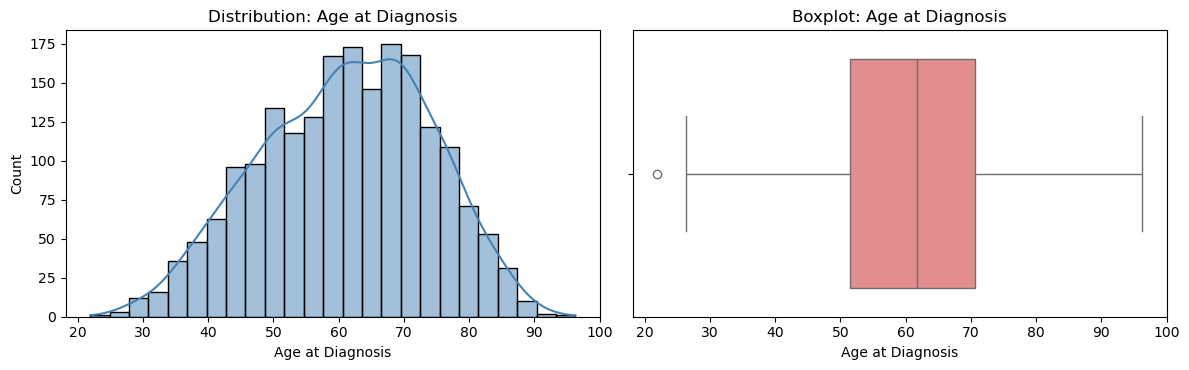

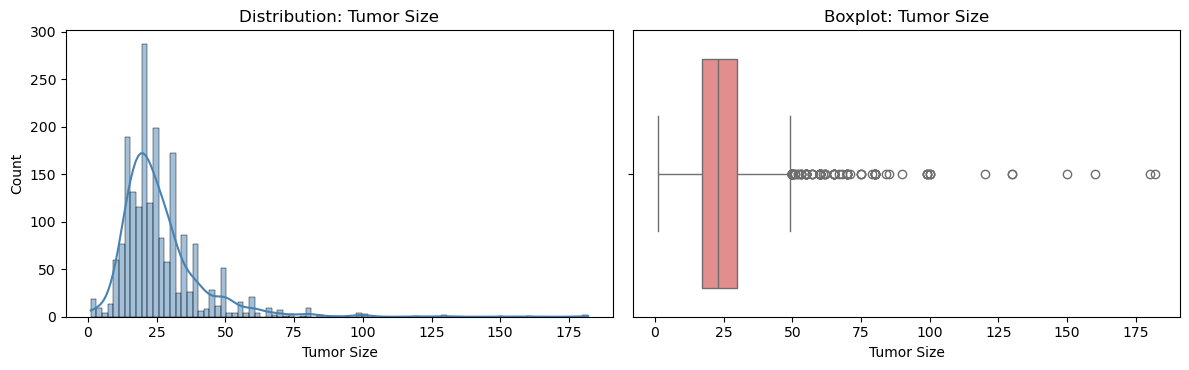

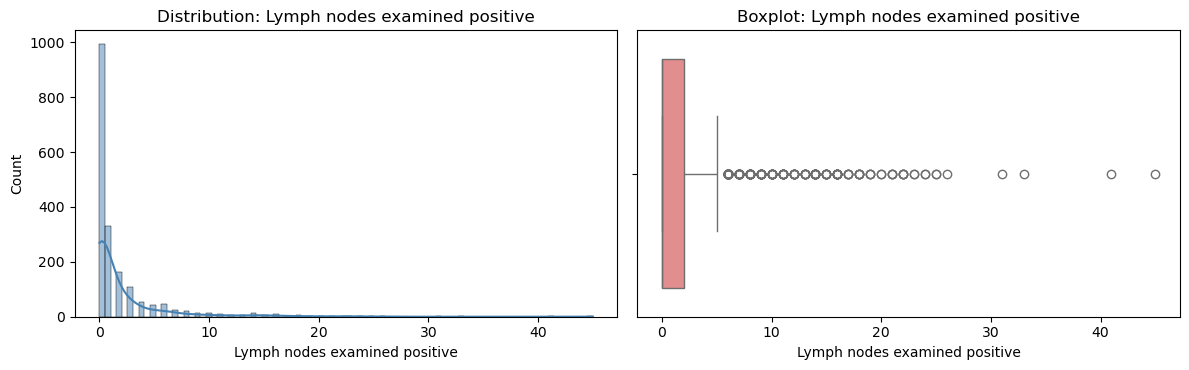

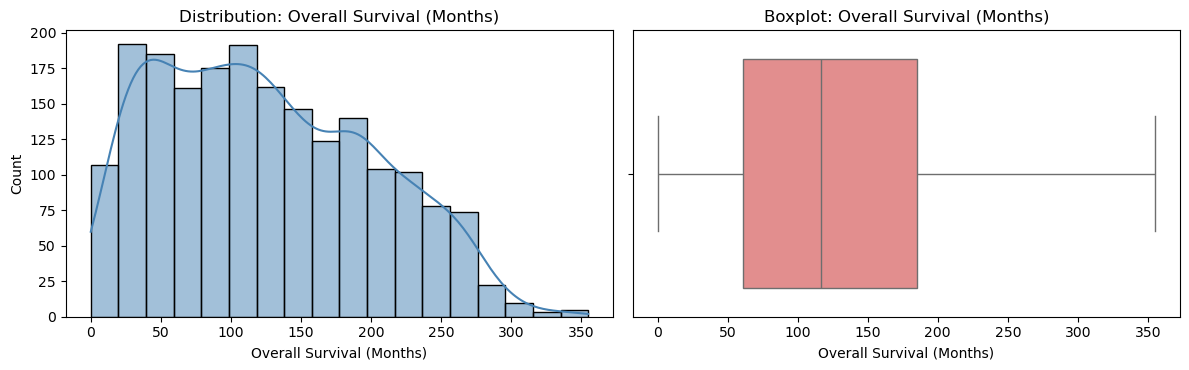

,feature,iqr_outliers,iqr_pct,zscore_outliers,zscore_pct
2,Lymph nodes examined positive,210,10.60,50,2.52
1,Tumor Size,151,7.62,30,1.51
0,Age at Diagnosis,1,0.05,1,0.05
3,Overall Survival (Months),0,0.00,1,0.05


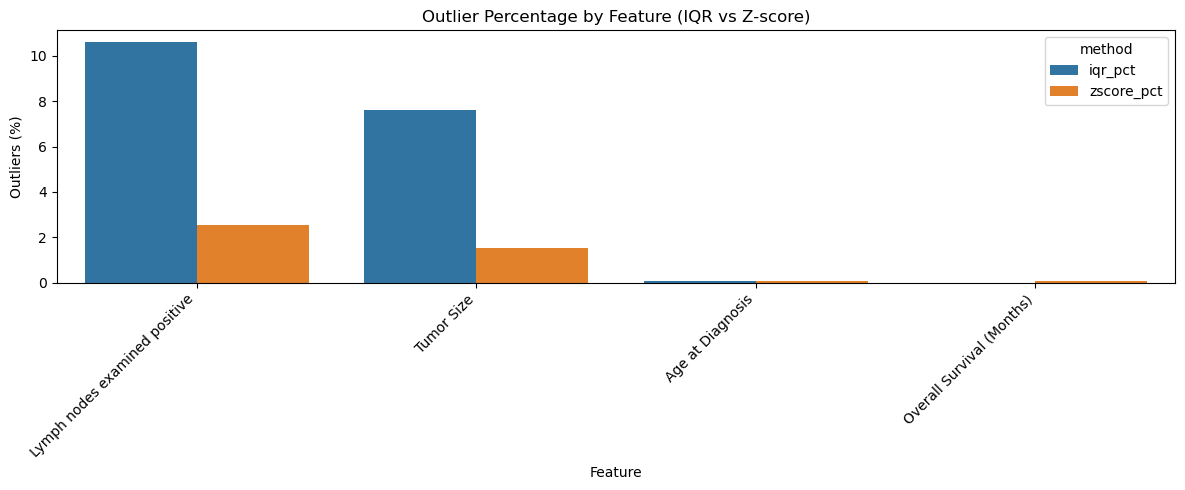

In [176]:
### visualize features and evaluate outliers (all numeric features)

# 1) Select numeric features
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric features:", numeric_cols)

if len(numeric_cols) == 0:
    print("No numeric features found for outlier analysis.")
else:
    # 2) Visual inspection: histogram + boxplot for each numeric feature
    for col in numeric_cols:
        fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

        sns.histplot(data[col].dropna(), kde=True, ax=axes[0], color="steelblue")
        axes[0].set_title(f"Distribution: {col}")
        axes[0].set_xlabel(col)

        sns.boxplot(x=data[col], ax=axes[1], color="lightcoral")
        axes[1].set_title(f"Boxplot: {col}")
        axes[1].set_xlabel(col)

        plt.tight_layout()
        plt.show()

    # 3) Quantitative outlier evaluation using IQR and Z-score
    outlier_rows = []
    n_rows = len(data)

    for col in numeric_cols:
        s = data[col].dropna()
        if len(s) == 0:
            outlier_rows.append({
                "feature": col,
                "iqr_outliers": 0,
                "iqr_pct": 0.0,
                "zscore_outliers": 0,
                "zscore_pct": 0.0
            })
            continue

        # IQR method
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        iqr_mask = (data[col] < lower) | (data[col] > upper)
        iqr_count = int(iqr_mask.fillna(False).sum())

        # Z-score method
        std = s.std(ddof=0)
        if std == 0:
            z_count = 0
        else:
            z_scores = (data[col] - s.mean()) / std
            z_mask = z_scores.abs() > 3
            z_count = int(z_mask.fillna(False).sum())

        outlier_rows.append({
            "feature": col,
            "iqr_outliers": iqr_count,
            "iqr_pct": round((iqr_count / n_rows) * 100, 2),
            "zscore_outliers": z_count,
            "zscore_pct": round((z_count / n_rows) * 100, 2),
        })

    outlier_summary = pd.DataFrame(outlier_rows).sort_values("iqr_outliers", ascending=False)
    display(outlier_summary)

    # 4) Summary bar plot for easy comparison
    plot_out = outlier_summary.melt(
        id_vars="feature",
        value_vars=["iqr_pct", "zscore_pct"],
        var_name="method",
        value_name="outlier_percent"
    )

    plt.figure(figsize=(12, 5))
    sns.barplot(data=plot_out, x="feature", y="outlier_percent", hue="method")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Outliers (%)")
    plt.xlabel("Feature")
    plt.title("Outlier Percentage by Feature (IQR vs Z-score)")
    plt.tight_layout()
    plt.show()

In [177]:
### outlier treatment after visualization

# Cap fixed thresholds in the full dataset before split
data["Tumor Size"] = data["Tumor Size"].clip(upper=100)
data["Lymph nodes examined positive"] = data["Lymph nodes examined positive"].clip(upper=10)

print("Tumor Size max after cap:", data["Tumor Size"].max())
print("Lymph nodes max after cap:", data["Lymph nodes examined positive"].max())


Tumor Size max after cap: 100.0
Lymph nodes max after cap: 10.0


In [178]:
### discretize overall survival (months) into 4 groups

for index, row in data.iterrows():
    if row["Overall Survival (Months)"]>=60:
        data.loc[index, "Survival Duration"] = ">=5 years"
    else:
        data.loc[index, "Survival Duration"] = "<5 years"

In [179]:
### split predictors and response

predictors=["Age at Diagnosis", 
              "Cancer Type Grouped", 
              "Inferred Menopausal State", 
              "Tumor Size",
              "Lymph nodes examined positive",
              "3-Gene classifier subtype",
              "Pam50 + Claudin-low subtype",
              "Integrative Cluster",
              "IHC Subtype"]

x= data[predictors]
y=data["Survival Duration"]

In [180]:
### split into test and train data 
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42)

In [181]:
### impute missing predictor values

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

# check NaNs
print(x_train.isna().sum())
print(x_test.isna().sum())

# impute menopausal status based on age
mask = x_test["Inferred Menopausal State"].isna()
x_test.loc[mask, "Inferred Menopausal State"] = np.where(
    x_test.loc[mask, "Age at Diagnosis"] < 52,
    "Pre",
    "Post")

# impute tumor size from training median
tumor_size_median = x_train["Tumor Size"].median()
x_train["Tumor Size"] = x_train["Tumor Size"].fillna(tumor_size_median)
x_test["Tumor Size"] = x_test["Tumor Size"].fillna(tumor_size_median)

# impute lymph nodes from training median
lymph_node_median = x_train["Lymph nodes examined positive"].median()
x_train["Lymph nodes examined positive"] = x_train["Lymph nodes examined positive"].fillna(lymph_node_median)
x_test["Lymph nodes examined positive"] = x_test["Lymph nodes examined positive"].fillna(lymph_node_median)

# special imputation for 3-gene classifier using KNN (fit on train only)
target_col = "3-Gene classifier subtype"
feature_cols = [c for c in x_train.columns if c != target_col]

train_known = x_train[x_train[target_col].notna()].copy()
train_missing = x_train[x_train[target_col].isna()].copy()
test_missing = x_test[x_test[target_col].isna()].copy()

if len(train_known) >= 2:
    num_cols = train_known[feature_cols].select_dtypes(include=["number"]).columns.tolist()
    cat_cols = [c for c in feature_cols if c not in num_cols]

    preprocess = ColumnTransformer(
        transformers=[
            ("num", "passthrough", num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ]
    )

    # odd k and not larger than available train rows
    k = int(np.sqrt(len(train_known)))
    if k % 2 == 0:
        k += 1
    k = max(1, min(k, len(train_known)))

    knn_model = Pipeline(steps=[
        ("prep", preprocess),
        ("knn", KNeighborsClassifier(n_neighbors=k, weights="distance")),
    ])

    knn_model.fit(train_known[feature_cols], train_known[target_col])

    if len(train_missing) > 0:
        x_train.loc[train_missing.index, target_col] = knn_model.predict(train_missing[feature_cols])

    if len(test_missing) > 0:
        x_test.loc[test_missing.index, target_col] = knn_model.predict(test_missing[feature_cols])
else:
    # fallback if there are not enough known labels in train
    three_gene_mode = x_train[target_col].mode()[0]
    x_train[target_col] = x_train[target_col].fillna(three_gene_mode)
    x_test[target_col] = x_test[target_col].fillna(three_gene_mode)

# impute Pam50 using training mode
pam50_mode = x_train["Pam50 + Claudin-low subtype"].mode()[0]
x_train["Pam50 + Claudin-low subtype"] = x_train["Pam50 + Claudin-low subtype"].fillna(pam50_mode)
x_test["Pam50 + Claudin-low subtype"] = x_test["Pam50 + Claudin-low subtype"].fillna(pam50_mode)

# impute IntCluster using training mode
int_cluster_mode = x_train["Integrative Cluster"].mode()[0]
x_train["Integrative Cluster"] = x_train["Integrative Cluster"].fillna(int_cluster_mode)
x_test["Integrative Cluster"] = x_test["Integrative Cluster"].fillna(int_cluster_mode)

print("\n3-Gene missing after KNN imputation (train):", x_train[target_col].isna().sum())
print("3-Gene missing after KNN imputation (test):", x_test[target_col].isna().sum())


Age at Diagnosis                   0
Cancer Type Grouped                0
Inferred Menopausal State          1
Tumor Size                        19
Lymph nodes examined positive     65
3-Gene classifier subtype        182
Pam50 + Claudin-low subtype        1
Integrative Cluster                1
IHC Subtype                        0
dtype: int64
Age at Diagnosis                  0
Cancer Type Grouped               0
Inferred Menopausal State         0
Tumor Size                        7
Lymph nodes examined positive    11
3-Gene classifier subtype        35
Pam50 + Claudin-low subtype       0
Integrative Cluster               0
IHC Subtype                       0
dtype: int64

3-Gene missing after KNN imputation (train): 0
3-Gene missing after KNN imputation (test): 0


In [182]:
# confirm NaNs are removed
print(x_train.isna().sum())
print(x_test.isna().sum())

Age at Diagnosis                 0
Cancer Type Grouped              0
Inferred Menopausal State        1
Tumor Size                       0
Lymph nodes examined positive    0
3-Gene classifier subtype        0
Pam50 + Claudin-low subtype      0
Integrative Cluster              0
IHC Subtype                      0
dtype: int64
Age at Diagnosis                 0
Cancer Type Grouped              0
Inferred Menopausal State        0
Tumor Size                       0
Lymph nodes examined positive    0
3-Gene classifier subtype        0
Pam50 + Claudin-low subtype      0
Integrative Cluster              0
IHC Subtype                      0
dtype: int64


In [183]:
### separate x train and x test for each model

# model 1 - baseline
x1=["Age at Diagnosis", 
    "Cancer Type Grouped", 
    "Inferred Menopausal State", 
    "Tumor Size",
    "Lymph nodes examined positive"]
x1_train= x_train[x1]
x1_test= x_test[x1]

# model 2 - baseline + 3-gene
x2= x1 + ["3-Gene classifier subtype"]
x2_train= x_train[x2]
x2_test= x_test[x2]

# model 3 - baseline + Pam50
x3= x1 + ["Pam50 + Claudin-low subtype"]
x3_train= x_train[x3]
x3_test= x_test[x3]

# model 4 - baseline + integrative cluster
x4= x1 + ["Integrative Cluster"]
x4_train= x_train[x4]
x4_test= x_test[x4]

# model 5 - baseline + IHC subtype
x5= x1 + ["IHC Subtype"]
x5_train= x_train[x5]
x5_test= x_test[x5]

# model 6 - model 5 + integrative cluster
x6= x5 + ["Integrative Cluster"]
x6_train= x_train[x6]
x6_test= x_test[x6]

# model 7 - model 5 + 3-gene
x7= x5 + ["3-Gene classifier subtype"]
x7_train= x_train[x7]
x7_test= x_test[x7]

# model 8 - model 5 + Pam50
x8= x5 + ["Pam50 + Claudin-low subtype"]
x8_train= x_train[x8]
x8_test= x_test[x8]

In [184]:
### One hot encode

x1_train = pd.get_dummies(x1_train)
x1_test = pd.get_dummies(x1_test)

x2_train = pd.get_dummies(x2_train)
x2_test = pd.get_dummies(x2_test)

x3_train = pd.get_dummies(x3_train)
x3_test = pd.get_dummies(x3_test)

x4_train = pd.get_dummies(x4_train)
x4_test = pd.get_dummies(x4_test)

x5_train = pd.get_dummies(x5_train)
x5_test = pd.get_dummies(x5_test)

x6_train = pd.get_dummies(x6_train)
x6_test = pd.get_dummies(x6_test)

x7_train = pd.get_dummies(x7_train)
x7_test = pd.get_dummies(x7_test)

x8_train = pd.get_dummies(x8_train)
x8_test = pd.get_dummies(x8_test)

In [185]:
### save datasets
x1_train.to_csv("./x1_train.csv", index=False)
x1_test.to_csv("./x1_test.csv", index=False)

x2_train.to_csv("./x2_train.csv", index=False)
x2_test.to_csv("./x2_test.csv", index=False)

x3_train.to_csv("./x3_train.csv", index=False)
x3_test.to_csv("./x3_test.csv", index=False)

x4_train.to_csv("./x4_train.csv", index=False)
x4_test.to_csv("./x4_test.csv", index=False)

x5_train.to_csv("./x5_train.csv", index=False)
x5_test.to_csv("./x5_test.csv", index=False)

x6_train.to_csv("./x6_train.csv", index=False)
x6_test.to_csv("./x6_test.csv", index=False)

x7_train.to_csv("./x7_train.csv", index=False)
x7_test.to_csv("./x7_test.csv", index=False)

x8_train.to_csv("./x8_train.csv", index=False)
x8_test.to_csv("./x8_test.csv", index=False)

y_train.to_csv("./y_train.csv", index=False)
y_test.to_csv("./y_test.csv", index=False)

In [186]:
### train and evaluate 8 random forest models for comparison

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

model_inputs = {
    "Model 1 - Baseline": (x1_train, x1_test),
    "Model 2 - Baseline + 3-Gene": (x2_train, x2_test),
    "Model 3 - Baseline + Pam50": (x3_train, x3_test),
    "Model 4 - Baseline + IntCluster": (x4_train, x4_test),
    "Model 5 - Baseline + IHC": (x5_train, x5_test),
    "Model 6 - IHC + IntCluster": (x6_train, x6_test),
    "Model 7 - IHC + 3-Gene": (x7_train, x7_test),
    "Model 8 - IHC + Pam50": (x8_train, x8_test),
}

results = []
cms = {}
positive_class = ">=5 years"

for model_name, (X_train_model, X_test_model) in model_inputs.items():
    # Align test columns to training columns after one-hot encoding
    X_test_aligned = X_test_model.reindex(columns=X_train_model.columns, fill_value=0)

    clf = RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        class_weight="balanced_subsample"
    )
    clf.fit(X_train_model, y_train)

    y_pred = clf.predict(X_test_aligned)
    cm = confusion_matrix(y_test, y_pred, labels=["<5 years", ">=5 years"] )
    cms[model_name] = cm

    y_true_bin = (y_test == positive_class).astype(int)
    if positive_class in clf.classes_:
        pos_idx = list(clf.classes_).index(positive_class)
        y_score = clf.predict_proba(X_test_aligned)[:, pos_idx]
        roc_auc = roc_auc_score(y_true_bin, y_score)
    else:
        roc_auc = np.nan

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, pos_label=positive_class, zero_division=0),
        "Recall": recall_score(y_test, y_pred, pos_label=positive_class, zero_division=0),
        "F1": f1_score(y_test, y_pred, pos_label=positive_class, zero_division=0),
        "ROC_AUC": roc_auc
    })

results_df = pd.DataFrame(results).sort_values("F1", ascending=False).reset_index(drop=True)
display(results_df)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Model 4 - Baseline + IntCluster,0.755668,0.788571,0.923077,0.850539,0.689185
1,Model 5 - Baseline + IHC,0.758186,0.797654,0.909699,0.850000,0.685755
2,Model 6 - IHC + IntCluster,0.755668,0.791908,0.916388,0.849612,0.707102
3,Model 7 - IHC + 3-Gene,0.750630,0.790698,0.909699,0.846034,0.670125
4,Model 8 - IHC + Pam50,0.748111,0.788406,0.909699,0.844720,0.684697
5,Model 2 - Baseline + 3-Gene,0.745592,0.786127,0.909699,0.843411,0.682018
6,Model 1 - Baseline,0.738035,0.785924,0.896321,0.837500,0.656815
7,Model 3 - Baseline + Pam50,0.730479,0.780702,0.892977,0.833073,0.674527


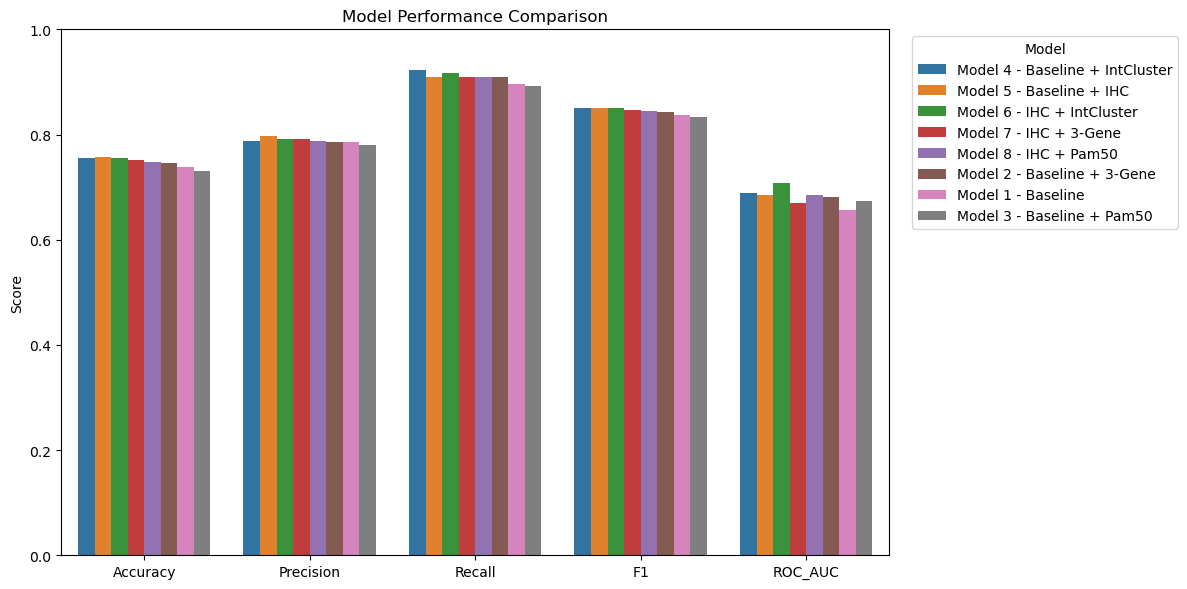

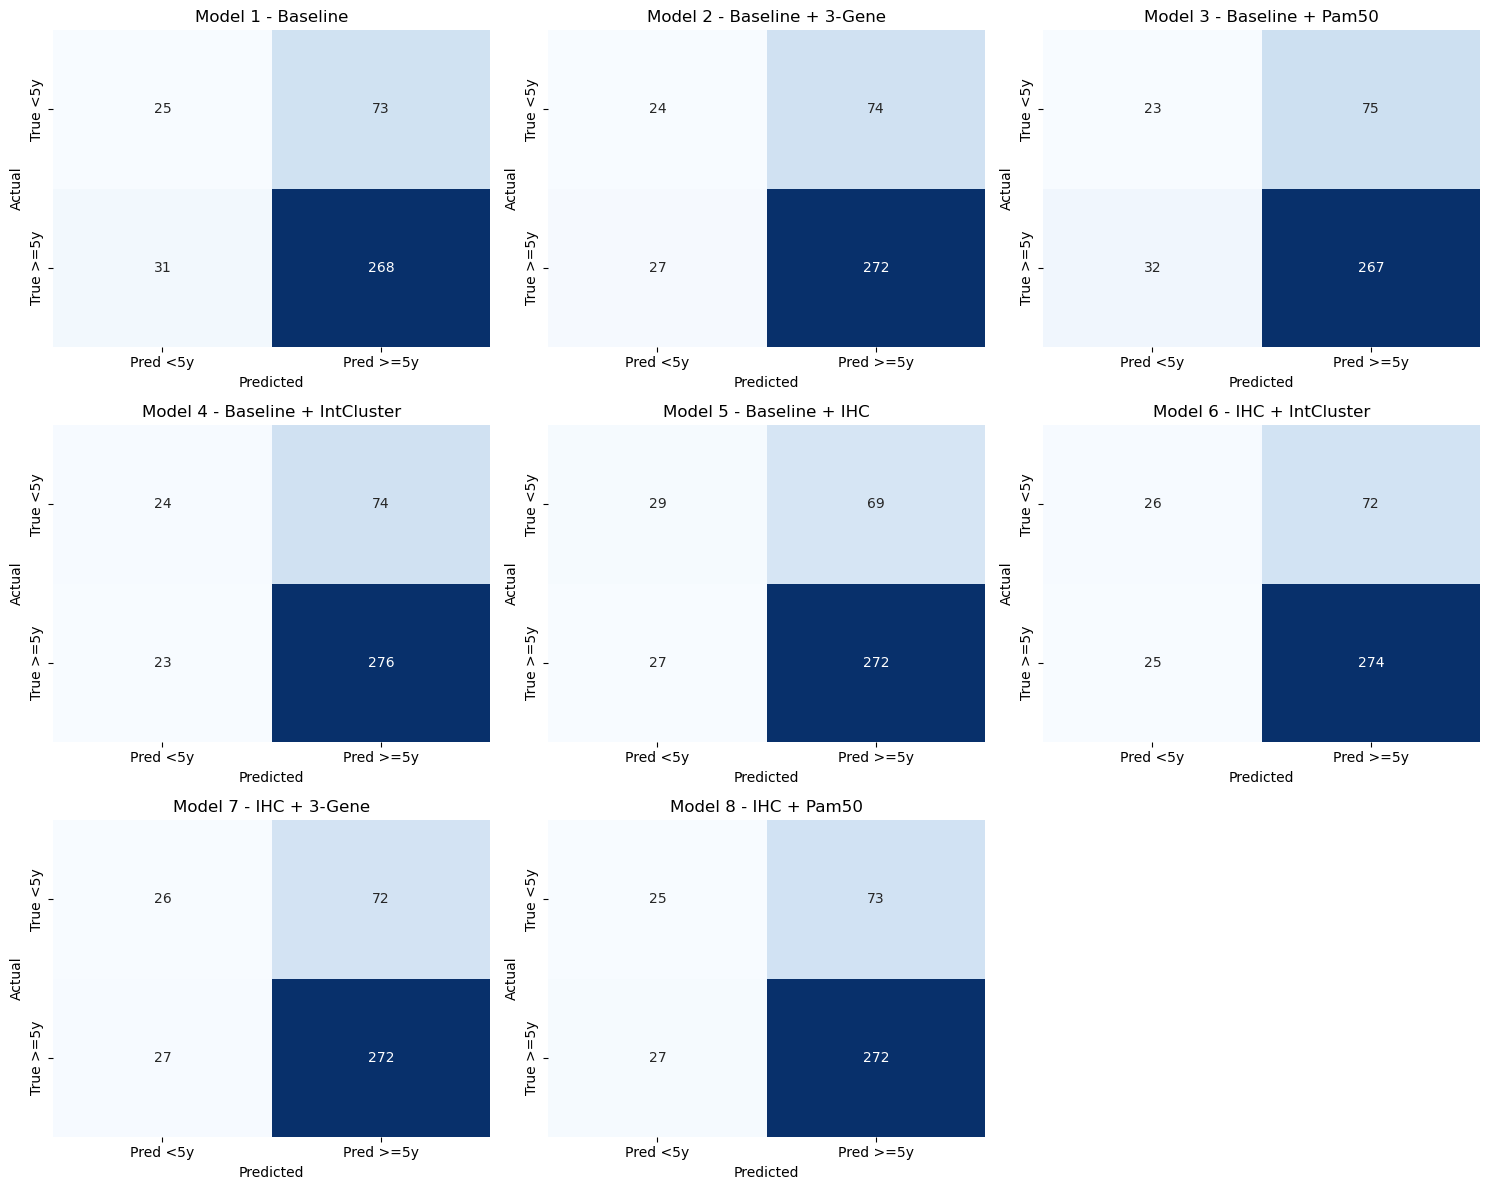

,Model,F1,ROC_AUC
0,Model 4 - Baseline + IntCluster,0.850539,0.689185
1,Model 5 - Baseline + IHC,0.850000,0.685755
2,Model 6 - IHC + IntCluster,0.849612,0.707102
3,Model 7 - IHC + 3-Gene,0.846034,0.670125
4,Model 8 - IHC + Pam50,0.844720,0.684697
5,Model 2 - Baseline + 3-Gene,0.843411,0.682018
6,Model 1 - Baseline,0.837500,0.656815
7,Model 3 - Baseline + Pam50,0.833073,0.674527


In [187]:
### visualize model performance

# 1) Metrics comparison chart
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
plot_df = results_df.melt(id_vars="Model", value_vars=metrics_to_plot,
                          var_name="Metric", value_name="Score")

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x="Metric", y="Score", hue="Model")
plt.ylim(0, 1)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 2) Confusion matrices
n_models = len(cms)
n_cols = 3
n_rows = int(np.ceil(n_models / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, (model_name, cm) in zip(axes, cms.items()):
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
        xticklabels=["Pred <5y", "Pred >=5y"],
        yticklabels=["True <5y", "True >=5y"]
    )
    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

for ax in axes[len(cms):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

# 3) Quick ranking by F1 and ROC-AUC
display(results_df[["Model", "F1", "ROC_AUC"]].sort_values("F1", ascending=False))

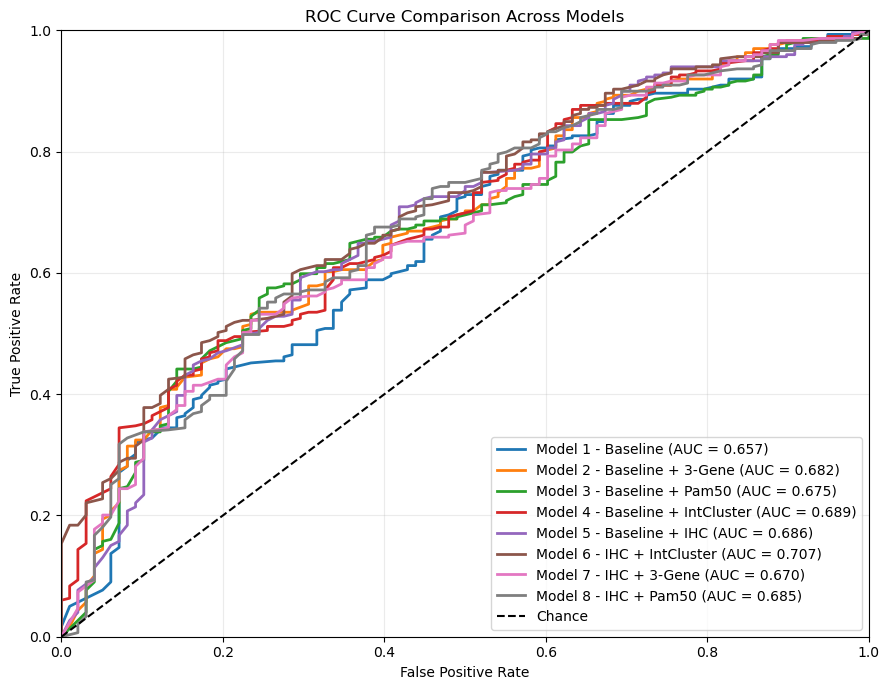

In [188]:
### ROC curves for all models

from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import RandomForestClassifier

positive_class = ">=5 years"
y_true_bin = (y_test == positive_class).astype(int)

plt.figure(figsize=(9, 7))

for model_name, (X_train_model, X_test_model) in model_inputs.items():
    # Align test columns to training columns after one-hot encoding
    X_test_aligned = X_test_model.reindex(columns=X_train_model.columns, fill_value=0)

    clf = RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        class_weight="balanced_subsample"
    )
    clf.fit(X_train_model, y_train)

    if positive_class in clf.classes_:
        pos_idx = list(clf.classes_).index(positive_class)
        y_score = clf.predict_proba(X_test_aligned)[:, pos_idx]
        fpr, tpr, _ = roc_curve(y_true_bin, y_score)
        roc_auc_value = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"{model_name} (AUC = {roc_auc_value:.3f})")

plt.plot([0, 1], [0, 1], "k--", lw=1.5, label="Chance")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison Across Models")
plt.legend(loc="lower right")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

,Model,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_mean,F1_std,ROC_AUC_mean,ROC_AUC_std
0,Model 8 - IHC + Pam50,0.744326,0.024111,0.787282,0.012725,0.904314,0.021942,0.841683,0.015500,0.670439,0.039070
1,Model 3 - Baseline + Pam50,0.740532,0.020841,0.786474,0.014488,0.899248,0.011243,0.839055,0.012306,0.673518,0.035704
2,Model 5 - Baseline + IHC,0.739256,0.025561,0.791020,0.018125,0.888320,0.019503,0.836712,0.015578,0.665686,0.031011
3,Model 6 - IHC + IntCluster,0.732326,0.027207,0.780638,0.017100,0.895879,0.016718,0.834276,0.016518,0.658579,0.027324
4,Model 7 - IHC + 3-Gene,0.731695,0.022082,0.785844,0.012665,0.884153,0.017964,0.832063,0.014017,0.659627,0.038873
5,Model 4 - Baseline + IntCluster,0.725390,0.027172,0.775323,0.017897,0.894199,0.021195,0.830413,0.016675,0.662355,0.032781
6,Model 1 - Baseline,0.726013,0.024994,0.782123,0.017002,0.881583,0.026586,0.828637,0.016158,0.655228,0.042518
7,Model 2 - Baseline + 3-Gene,0.722220,0.033224,0.779573,0.018430,0.879108,0.027078,0.826288,0.021220,0.656591,0.040987


,Model,F1_mean,F1_std,ROC_AUC_mean,ROC_AUC_std
0,Model 8 - IHC + Pam50,0.841683,0.015500,0.670439,0.039070
1,Model 3 - Baseline + Pam50,0.839055,0.012306,0.673518,0.035704
2,Model 5 - Baseline + IHC,0.836712,0.015578,0.665686,0.031011
3,Model 6 - IHC + IntCluster,0.834276,0.016518,0.658579,0.027324
4,Model 7 - IHC + 3-Gene,0.832063,0.014017,0.659627,0.038873
5,Model 4 - Baseline + IntCluster,0.830413,0.016675,0.662355,0.032781
6,Model 1 - Baseline,0.828637,0.016158,0.655228,0.042518
7,Model 2 - Baseline + 3-Gene,0.826288,0.021220,0.656591,0.040987


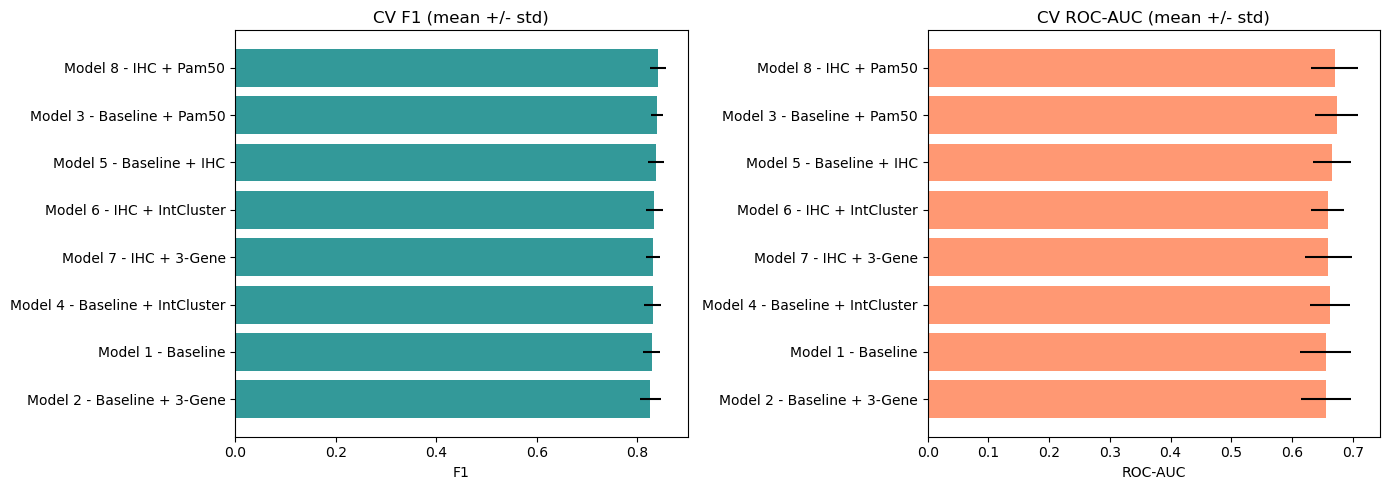

In [189]:
### cross-validation ranking for the 8 models (robust comparison)

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier

# Use the same positive class definition as before
positive_class = ">=5 years"
y_train_bin = (y_train == positive_class).astype(int)

cv_model_inputs = {
    "Model 1 - Baseline": x1_train,
    "Model 2 - Baseline + 3-Gene": x2_train,
    "Model 3 - Baseline + Pam50": x3_train,
    "Model 4 - Baseline + IntCluster": x4_train,
    "Model 5 - Baseline + IHC": x5_train,
    "Model 6 - IHC + IntCluster": x6_train,
    "Model 7 - IHC + 3-Gene": x7_train,
    "Model 8 - IHC + Pam50": x8_train,
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

cv_rows = []

for model_name, X_model in cv_model_inputs.items():
    clf = RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        class_weight="balanced_subsample"
    )

    cv_res = cross_validate(
        clf,
        X_model,
        y_train_bin,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    cv_rows.append({
        "Model": model_name,
        "Accuracy_mean": cv_res["test_accuracy"].mean(),
        "Accuracy_std": cv_res["test_accuracy"].std(),
        "Precision_mean": cv_res["test_precision"].mean(),
        "Precision_std": cv_res["test_precision"].std(),
        "Recall_mean": cv_res["test_recall"].mean(),
        "Recall_std": cv_res["test_recall"].std(),
        "F1_mean": cv_res["test_f1"].mean(),
        "F1_std": cv_res["test_f1"].std(),
        "ROC_AUC_mean": cv_res["test_roc_auc"].mean(),
        "ROC_AUC_std": cv_res["test_roc_auc"].std(),
    })

cv_results_df = pd.DataFrame(cv_rows).sort_values("F1_mean", ascending=False).reset_index(drop=True)
display(cv_results_df)

# Compact ranking view
display(cv_results_df[["Model", "F1_mean", "F1_std", "ROC_AUC_mean", "ROC_AUC_std"]])

# Visual comparison with error bars
plot_rank = cv_results_df.copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

axes[0].barh(plot_rank["Model"], plot_rank["F1_mean"], xerr=plot_rank["F1_std"], color="teal", alpha=0.8)
axes[0].invert_yaxis()
axes[0].set_title("CV F1 (mean +/- std)")
axes[0].set_xlabel("F1")

axes[1].barh(plot_rank["Model"], plot_rank["ROC_AUC_mean"], xerr=plot_rank["ROC_AUC_std"], color="coral", alpha=0.8)
axes[1].invert_yaxis()
axes[1].set_title("CV ROC-AUC (mean +/- std)")
axes[1].set_xlabel("ROC-AUC")

plt.tight_layout()
plt.show()

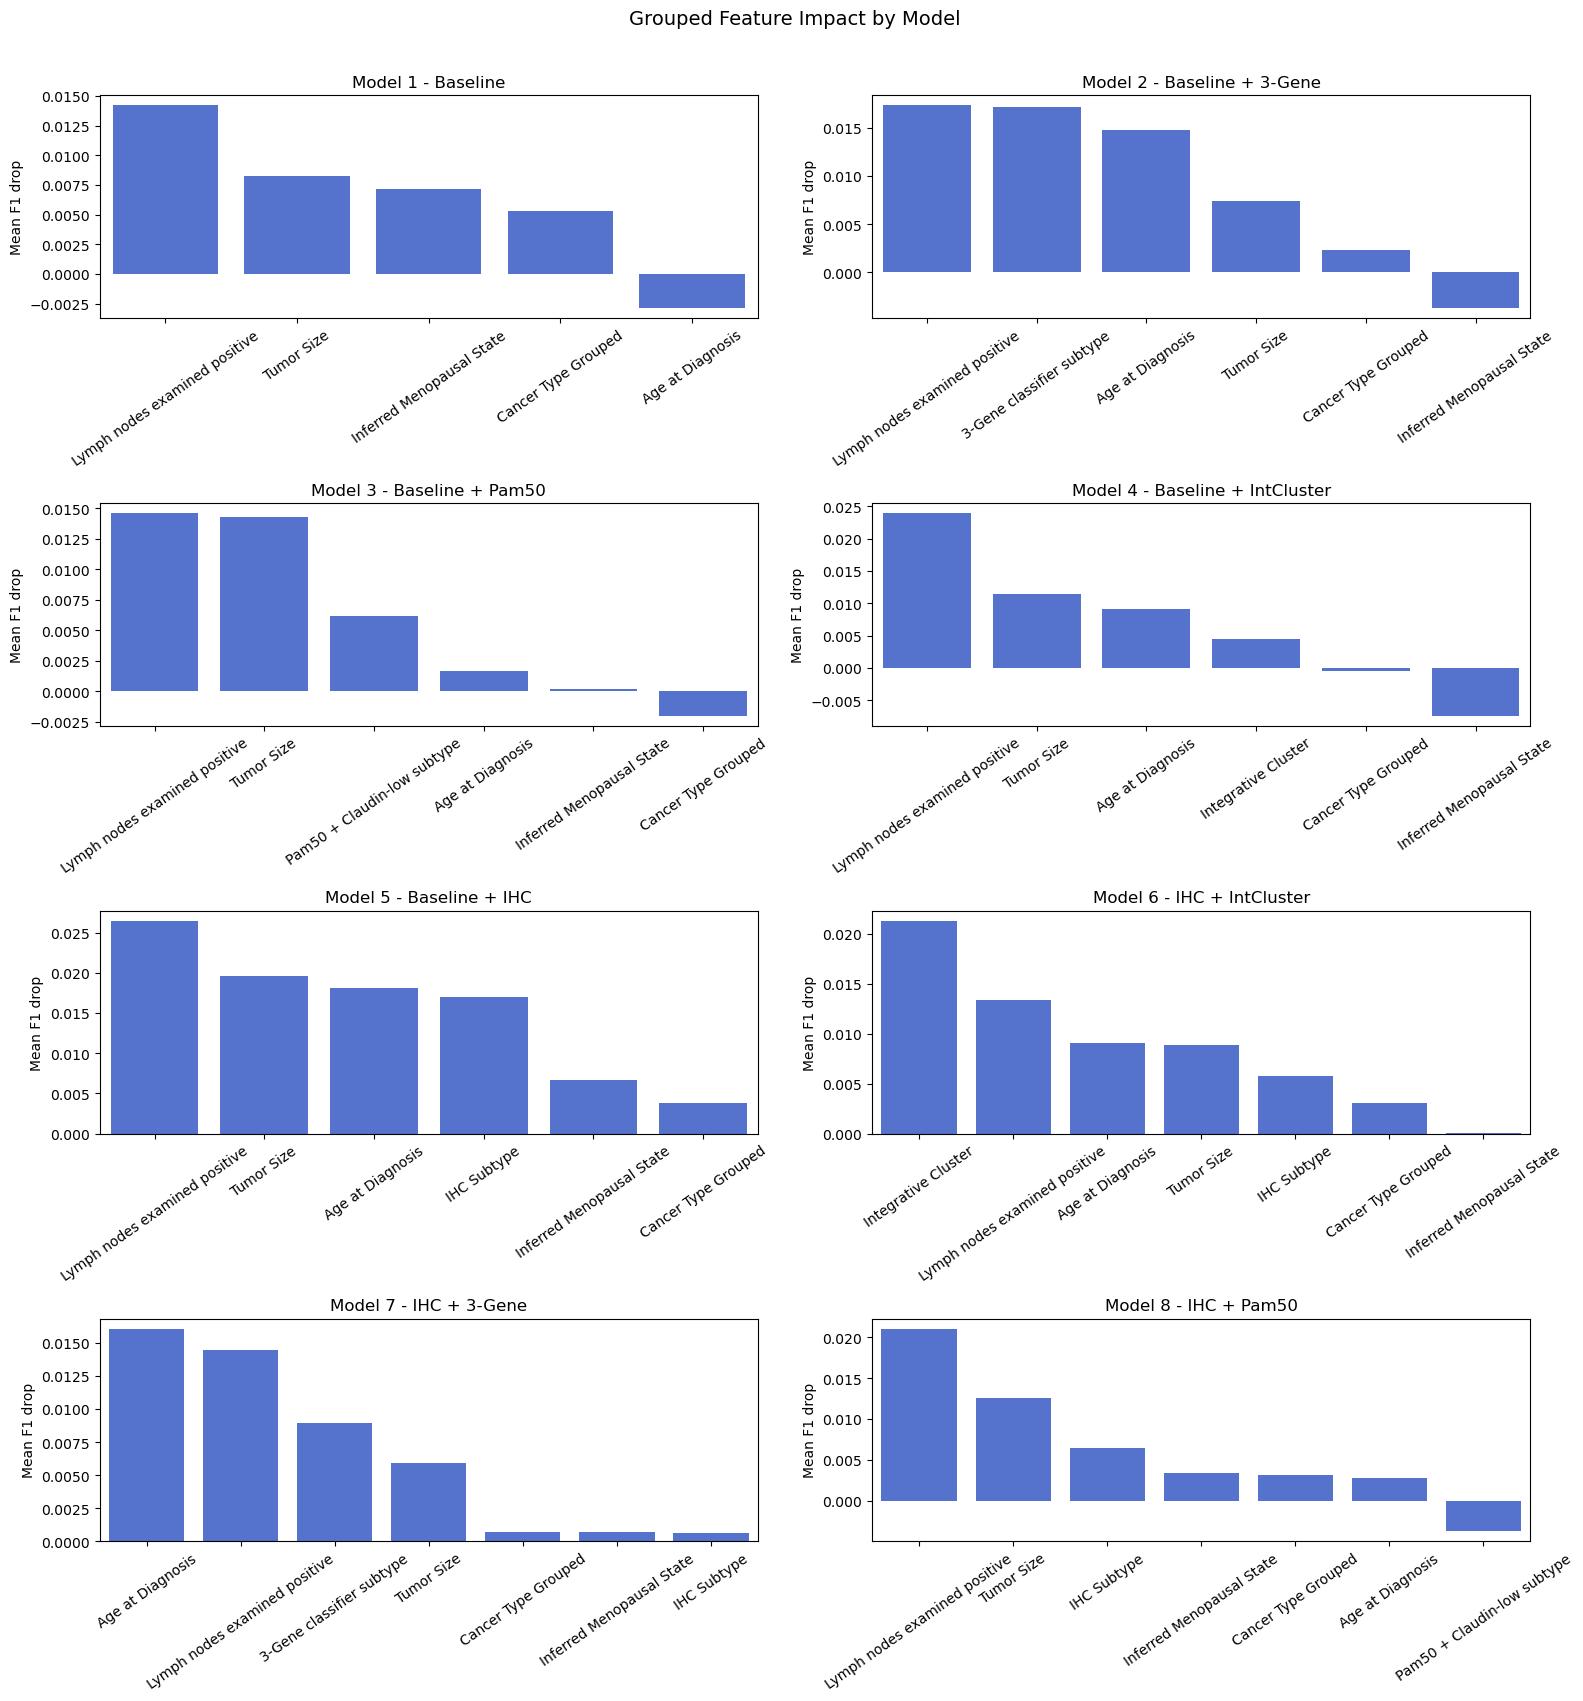

In [195]:
### grouped feature impact by model (permutation importance by original feature)

from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier

# Map each model to its original (pre one-hot) features
raw_feature_map = {
    "Model 1 - Baseline": x1,
    "Model 2 - Baseline + 3-Gene": x2,
    "Model 3 - Baseline + Pam50": x3,
    "Model 4 - Baseline + IntCluster": x4,
    "Model 5 - Baseline + IHC": x5,
    "Model 6 - IHC + IntCluster": x6,
    "Model 7 - IHC + 3-Gene": x7,
    "Model 8 - IHC + Pam50": x8,
}

# Train one model per feature set and compute grouped permutation impact on test
grouped_importance_rows = []
n_repeats = 5
rng = np.random.RandomState(42)

for model_name, (X_train_model, X_test_model) in model_inputs.items():
    X_test_aligned = X_test_model.reindex(columns=X_train_model.columns, fill_value=0)

    clf = RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        class_weight="balanced_subsample"
    )
    clf.fit(X_train_model, y_train)

    y_pred_base = clf.predict(X_test_aligned)
    baseline_f1 = f1_score(y_test, y_pred_base, pos_label=">=5 years", zero_division=0)

    for feat in raw_feature_map[model_name]:
        feat_cols = [c for c in X_test_aligned.columns if (c == feat) or c.startswith(feat + "_")]
        if len(feat_cols) == 0:
            continue

        f1_drops = []
        for _ in range(n_repeats):
            X_perm = X_test_aligned.copy()
            perm_idx = rng.permutation(len(X_perm))
            X_perm.loc[:, feat_cols] = X_perm[feat_cols].iloc[perm_idx].to_numpy()

            y_pred_perm = clf.predict(X_perm)
            f1_perm = f1_score(y_test, y_pred_perm, pos_label=">=5 years", zero_division=0)
            f1_drops.append(baseline_f1 - f1_perm)

        grouped_importance_rows.append({
            "Model": model_name,
            "Feature": feat,
            "Impact_F1_drop_mean": float(np.mean(f1_drops)),
        })

impact_df = pd.DataFrame(grouped_importance_rows)

# Per-model bar charts only
model_order = list(raw_feature_map.keys())
n_models = len(model_order)
n_cols = 2
n_rows = int(np.ceil(n_models / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4.2 * n_rows))
axes = np.array(axes).reshape(-1)

for i, model_name in enumerate(model_order):
    ax = axes[i]
    df_m = impact_df[impact_df["Model"] == model_name].sort_values("Impact_F1_drop_mean", ascending=False)

    sns.barplot(
        data=df_m,
        x="Feature",
        y="Impact_F1_drop_mean",
        color="royalblue",
        ax=ax
    )
    ax.set_title(model_name)
    ax.set_xlabel("")
    ax.set_ylabel("Mean F1 drop")
    ax.tick_params(axis="x", rotation=35)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Grouped Feature Impact by Model", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

,Model,Feature,Grouped_SHAP,Encoded_Columns
0,Model 1 - Baseline,Age at Diagnosis,0.146176,1
3,Model 1 - Baseline,Tumor Size,0.105843,1
4,Model 1 - Baseline,Lymph nodes examined positive,0.096368,1
1,Model 1 - Baseline,Cancer Type Grouped,0.033091,4
2,Model 1 - Baseline,Inferred Menopausal State,0.021330,2
5,Model 2 - Baseline + 3-Gene,Age at Diagnosis,0.119681,1
8,Model 2 - Baseline + 3-Gene,Tumor Size,0.100037,1
10,Model 2 - Baseline + 3-Gene,3-Gene classifier subtype,0.098193,4
9,Model 2 - Baseline + 3-Gene,Lymph nodes examined positive,0.089734,1
6,Model 2 - Baseline + 3-Gene,Cancer Type Grouped,0.024527,4


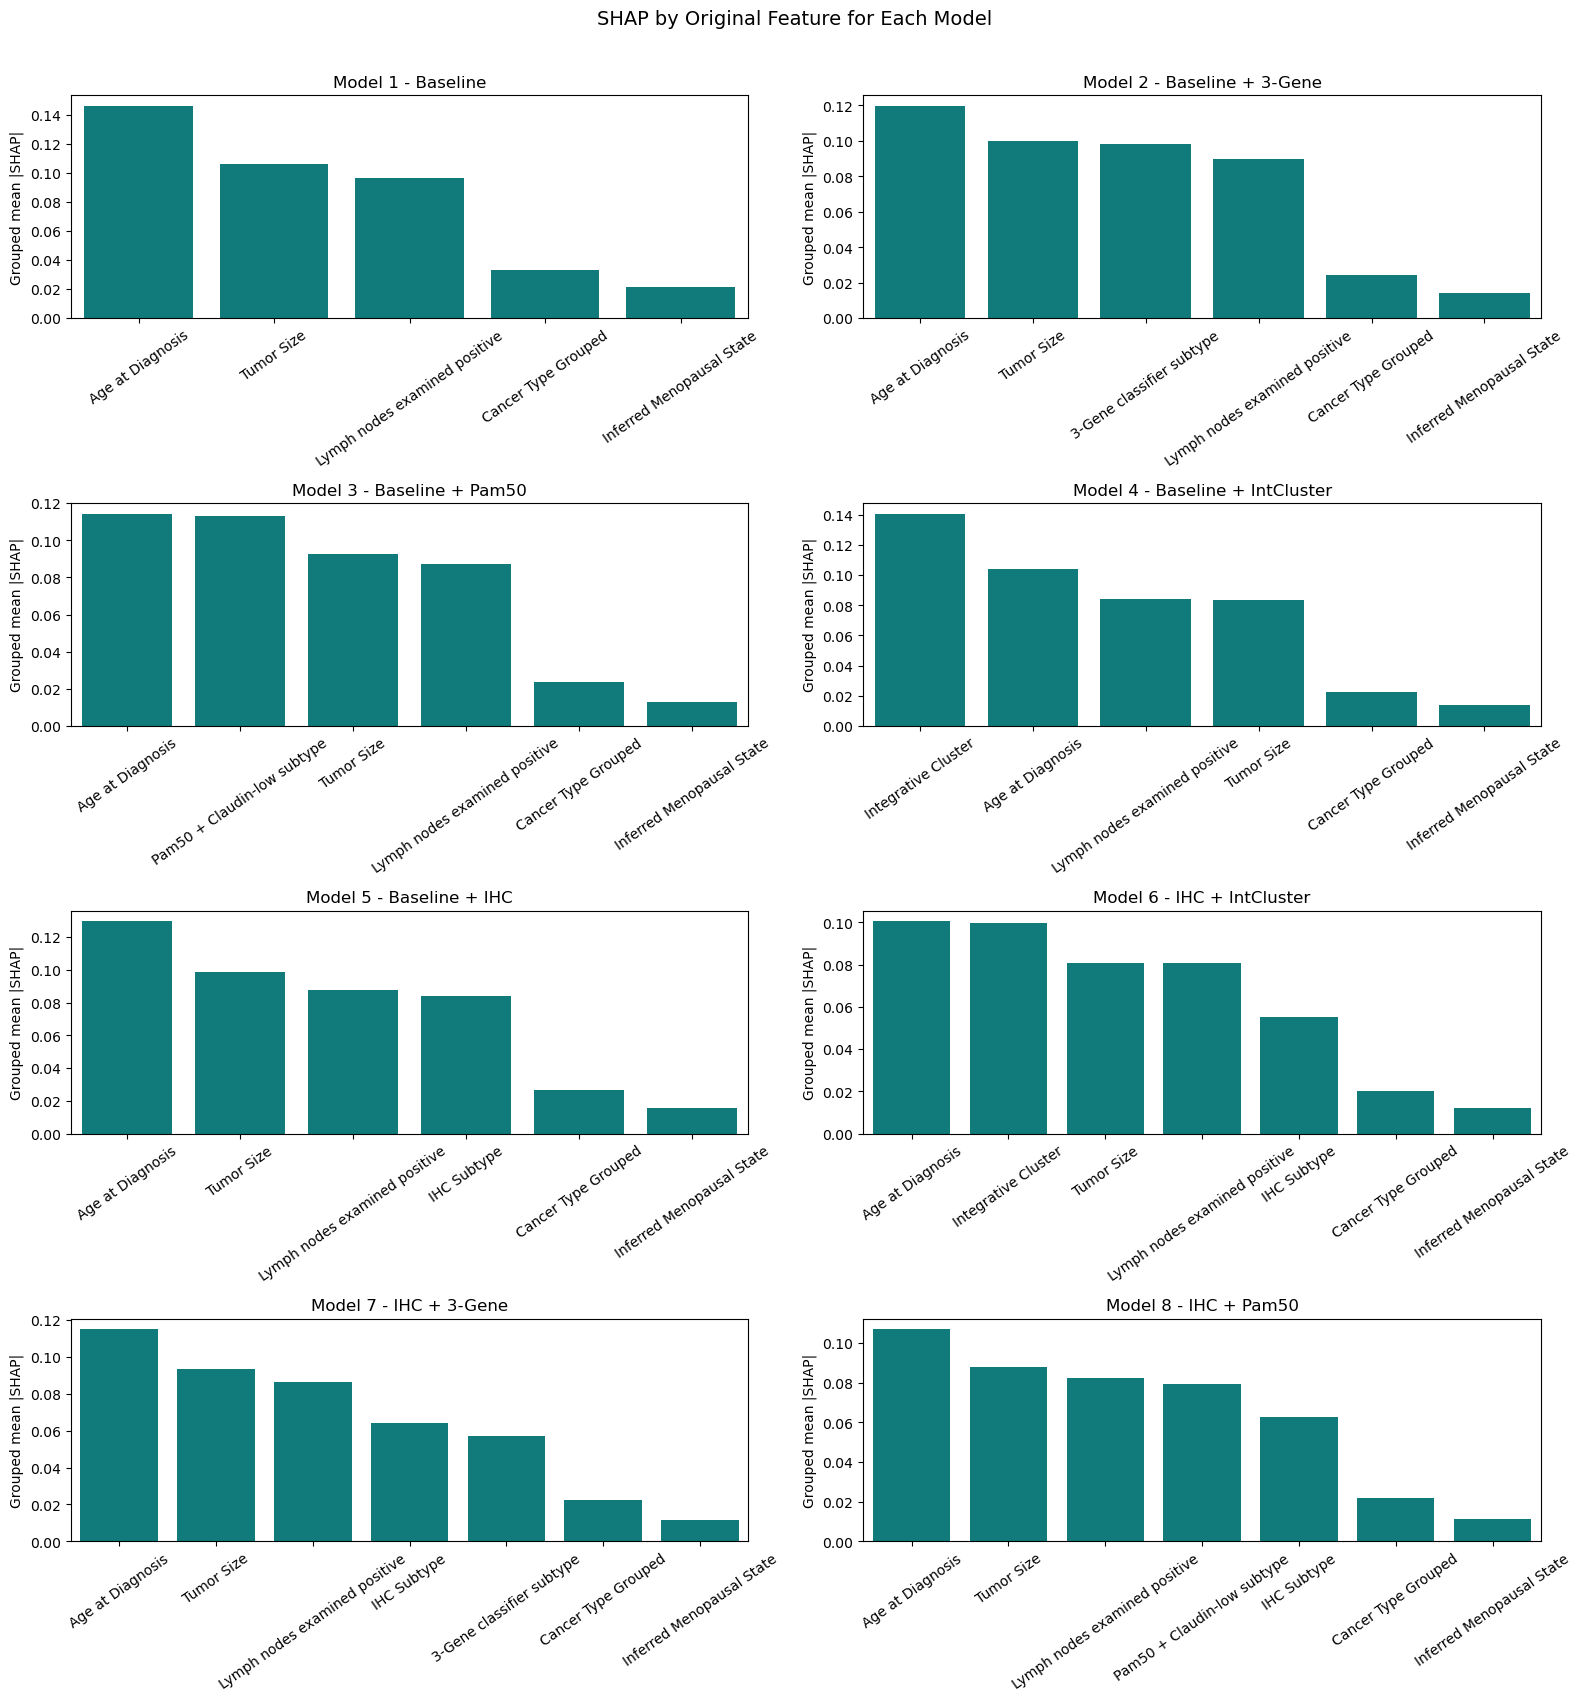

,Model,Feature,Grouped_SHAP,Encoded_Columns
10,Model 2 - Baseline + 3-Gene,3-Gene classifier subtype,0.098193,4
42,Model 7 - IHC + 3-Gene,3-Gene classifier subtype,0.056886,4
0,Model 1 - Baseline,Age at Diagnosis,0.146176,1
23,Model 5 - Baseline + IHC,Age at Diagnosis,0.129532,1
5,Model 2 - Baseline + 3-Gene,Age at Diagnosis,0.119681,1
36,Model 7 - IHC + 3-Gene,Age at Diagnosis,0.114886,1
11,Model 3 - Baseline + Pam50,Age at Diagnosis,0.114337,1
43,Model 8 - IHC + Pam50,Age at Diagnosis,0.106903,1
17,Model 4 - Baseline + IntCluster,Age at Diagnosis,0.104246,1
29,Model 6 - IHC + IntCluster,Age at Diagnosis,0.100405,1


In [194]:
### SHAP per model (8 models) grouped by original feature

# Ensure SHAP is available
try:
    import shap
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap", "-q"])
    import shap

from sklearn.ensemble import RandomForestClassifier

# Map each model to original feature list (before one-hot encoding)
raw_feature_map = {
    "Model 1 - Baseline": x1,
    "Model 2 - Baseline + 3-Gene": x2,
    "Model 3 - Baseline + Pam50": x3,
    "Model 4 - Baseline + IntCluster": x4,
    "Model 5 - Baseline + IHC": x5,
    "Model 6 - IHC + IntCluster": x6,
    "Model 7 - IHC + 3-Gene": x7,
    "Model 8 - IHC + Pam50": x8,
}

# Compute grouped SHAP importances per model
per_model_shap_rows = []
max_test_rows = 400  # speed control for SHAP

for model_name, (X_train_model, X_test_model) in model_inputs.items():
    X_test_aligned = X_test_model.reindex(columns=X_train_model.columns, fill_value=0)

    # Use a test subsample for faster SHAP on larger sets
    if len(X_test_aligned) > max_test_rows:
        X_test_for_shap = X_test_aligned.sample(n=max_test_rows, random_state=42)
    else:
        X_test_for_shap = X_test_aligned.copy()

    clf = RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        class_weight="balanced_subsample"
    )
    clf.fit(X_train_model, y_train)

    explainer = shap.TreeExplainer(clf)
    shap_values = explainer.shap_values(X_test_for_shap)

    # compatibility across SHAP versions
    if isinstance(shap_values, list):
        shap_pos = shap_values[1] if len(shap_values) > 1 else shap_values[0]
    else:
        if getattr(shap_values, "ndim", 0) == 3:
            shap_pos = shap_values[:, :, 1] if shap_values.shape[2] > 1 else shap_values[:, :, 0]
        else:
            shap_pos = shap_values

    mean_abs_shap = pd.Series(
        np.abs(shap_pos).mean(axis=0),
        index=X_test_for_shap.columns,
        name="mean_abs_shap"
    )

    for feat in raw_feature_map[model_name]:
        cols = [c for c in mean_abs_shap.index if (c == feat) or c.startswith(feat + "_")]
        total_shap = mean_abs_shap.loc[cols].sum() if len(cols) > 0 else 0.0
        per_model_shap_rows.append({
            "Model": model_name,
            "Feature": feat,
            "Grouped_SHAP": float(total_shap),
            "Encoded_Columns": len(cols),
        })

per_model_shap_df = pd.DataFrame(per_model_shap_rows)
display(per_model_shap_df.sort_values(["Model", "Grouped_SHAP"], ascending=[True, False]))

# Plot one bar chart per model
model_order = list(raw_feature_map.keys())
n_models = len(model_order)
n_cols = 2
n_rows = int(np.ceil(n_models / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4.2 * n_rows))
axes = np.array(axes).reshape(-1)

for i, model_name in enumerate(model_order):
    ax = axes[i]
    df_m = per_model_shap_df[per_model_shap_df["Model"] == model_name].sort_values("Grouped_SHAP", ascending=False)

    sns.barplot(data=df_m, x="Feature", y="Grouped_SHAP", color="darkcyan", ax=ax)
    ax.set_title(model_name)
    ax.set_xlabel("")
    ax.set_ylabel("Grouped mean |SHAP|")
    ax.tick_params(axis="x", rotation=35)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("SHAP by Original Feature for Each Model", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

# Optional comparison table only for key biomarker features
focus_features = [
    "IHC Subtype",
    "3-Gene classifier subtype",
    "Pam50 + Claudin-low subtype",
    "Integrative Cluster",
    "Age at Diagnosis",
    "Tumor Size",
    "Cancer Type Grouped",
]
focus_shap = per_model_shap_df[per_model_shap_df["Feature"].isin(focus_features)].copy()
display(focus_shap.sort_values(["Feature", "Grouped_SHAP"], ascending=[True, False]))

Best model used for subgroup evaluation: Model 4 - Baseline + IntCluster
Overall test metrics:


,Accuracy,Precision,Recall,F1
0,0.7557,0.7886,0.9231,0.8505


Subgroup metrics:


,Subgroup_Type,Subgroup_Value,N,PositiveRate_True,PositiveRate_Pred,Accuracy,Precision,Recall,F1
0,Cancer Type Grouped,Other,13,0.8462,1.0000,0.8462,0.8462,1.0000,0.9167
1,Cancer Type Grouped,Breast Invasive Lobular Carcinoma,33,0.7576,0.9394,0.8182,0.8065,1.0000,0.8929
2,Cancer Type Grouped,Breast Mixed Ductal and Lobular Carcinoma,40,0.8000,1.0000,0.8000,0.8000,1.0000,0.8889
3,Cancer Type Grouped,Breast Invasive Ductal Carcinoma,311,0.7428,0.8553,0.7395,0.7820,0.9004,0.8370
4,IHC Subtype,Luminal,289,0.7924,0.9204,0.7958,0.8195,0.9520,0.8808
5,IHC Subtype,Triple Negative,60,0.6833,0.8000,0.6500,0.7083,0.8293,0.7640
6,IHC Subtype,HER2,48,0.6042,0.7500,0.6458,0.6667,0.8276,0.7385
7,Inferred Menopausal State,Post,297,0.7643,0.9024,0.7677,0.7948,0.9383,0.8606
8,Inferred Menopausal State,Pre,100,0.7200,0.8200,0.7200,0.7683,0.8750,0.8182


Performance disparity (max-min) within each subgroup type:


,Subgroup_Type,Metric,Max,Min,Gap
4,IHC Subtype,Accuracy,0.7958,0.6458,0.1500
0,Cancer Type Grouped,Accuracy,0.8462,0.7395,0.1066
8,Inferred Menopausal State,Accuracy,0.7677,0.7200,0.0477
7,IHC Subtype,F1,0.8808,0.7385,0.1423
3,Cancer Type Grouped,F1,0.9167,0.8370,0.0796
11,Inferred Menopausal State,F1,0.8606,0.8182,0.0424
5,IHC Subtype,Precision,0.8195,0.6667,0.1529
1,Cancer Type Grouped,Precision,0.8462,0.7820,0.0642
9,Inferred Menopausal State,Precision,0.7948,0.7683,0.0265
6,IHC Subtype,Recall,0.9520,0.8276,0.1244


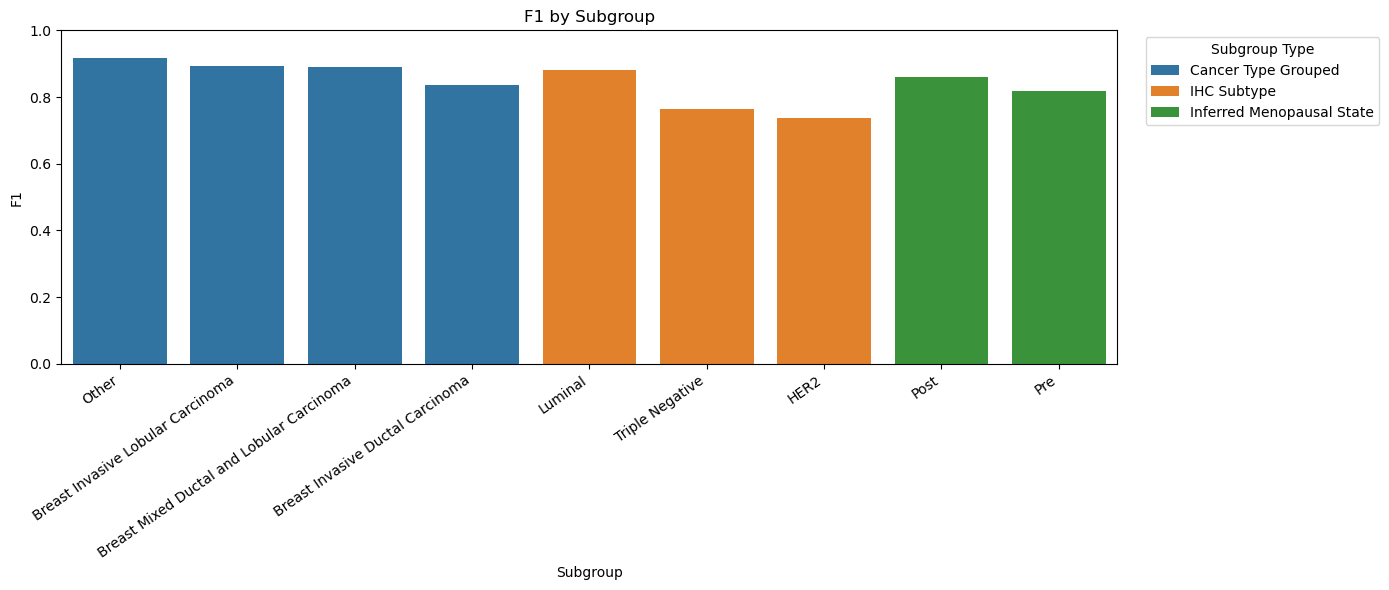

In [202]:
### subgroup evaluation (fairness/performance by cohort)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Required objects from previous cells
required_objs = ["results_df", "model_inputs", "x_test", "y_test", "y_train"]
missing_objs = [obj for obj in required_objs if obj not in globals()]
if missing_objs:
    raise ValueError(f"Missing required objects: {missing_objs}. Run training/evaluation cells first.")

positive_class = ">=5 years"

# 1) Train best model (by test F1 from results_df) and predict on its aligned test matrix
best_model_name = results_df.sort_values("F1", ascending=False).iloc[0]["Model"]
X_train_best, X_test_best = model_inputs[best_model_name]
X_test_best_aligned = X_test_best.reindex(columns=X_train_best.columns, fill_value=0)

clf_best = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight="balanced_subsample"
)
clf_best.fit(X_train_best, y_train)
y_pred = pd.Series(clf_best.predict(X_test_best_aligned), index=y_test.index, name="y_pred")

# 2) Build subgroup metrics table
subgroup_cols = [
    "IHC Subtype",
    "Inferred Menopausal State",
    "Cancer Type Grouped",
]

overall_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, pos_label=positive_class, zero_division=0),
    "Recall": recall_score(y_test, y_pred, pos_label=positive_class, zero_division=0),
    "F1": f1_score(y_test, y_pred, pos_label=positive_class, zero_division=0),
}

rows = []
for col in subgroup_cols:
    if col not in x_test.columns:
        print(f"Warning: {col} not found in x_test. Skipping this subgroup.")
        continue

    subgroup_series = x_test[col].copy().astype("object").fillna("Missing")

    for subgroup_value, idx in subgroup_series.groupby(subgroup_series).groups.items():
        y_true_g = y_test.loc[idx]
        y_pred_g = y_pred.loc[idx]
        n_g = len(y_true_g)

        if n_g == 0:
            continue

        rows.append({
            "Subgroup_Type": col,
            "Subgroup_Value": subgroup_value,
            "N": n_g,
            "PositiveRate_True": (y_true_g == positive_class).mean(),
            "PositiveRate_Pred": (y_pred_g == positive_class).mean(),
            "Accuracy": accuracy_score(y_true_g, y_pred_g),
            "Precision": precision_score(y_true_g, y_pred_g, pos_label=positive_class, zero_division=0),
            "Recall": recall_score(y_true_g, y_pred_g, pos_label=positive_class, zero_division=0),
            "F1": f1_score(y_true_g, y_pred_g, pos_label=positive_class, zero_division=0),
        })

subgroup_results_df = pd.DataFrame(rows)

if len(subgroup_results_df) == 0:
    print("No subgroup metrics could be computed.")
else:
    subgroup_results_df = subgroup_results_df.sort_values(["Subgroup_Type", "F1"], ascending=[True, False]).reset_index(drop=True)

    print("Best model used for subgroup evaluation:", best_model_name)
    print("Overall test metrics:")
    display(pd.DataFrame([overall_metrics]).round(4))

    print("Subgroup metrics:")
    display(subgroup_results_df.round(4))

    # 3) Gap analysis per subgroup type (max - min)
    gap_rows = []
    for sg_type, df_sg in subgroup_results_df.groupby("Subgroup_Type"):
        for metric in ["Accuracy", "Precision", "Recall", "F1"]:
            metric_vals = df_sg[metric]
            gap_rows.append({
                "Subgroup_Type": sg_type,
                "Metric": metric,
                "Max": metric_vals.max(),
                "Min": metric_vals.min(),
                "Gap": metric_vals.max() - metric_vals.min(),
            })

    subgroup_gap_df = pd.DataFrame(gap_rows).sort_values(["Metric", "Gap"], ascending=[True, False])
    print("Performance disparity (max-min) within each subgroup type:")
    display(subgroup_gap_df.round(4))

    # 4) Visual summary: F1 per subgroup
    plt.figure(figsize=(14, 6))
    sns.barplot(
        data=subgroup_results_df,
        x="Subgroup_Value",
        y="F1",
        hue="Subgroup_Type"
    )
    plt.xticks(rotation=35, ha="right")
    plt.ylim(0, 1)
    plt.title("F1 by Subgroup")
    plt.xlabel("Subgroup")
    plt.ylabel("F1")
    plt.legend(title="Subgroup Type", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

